# Signal Analysis — Cold Pressor Test (PPG & EDA)

## Protocol
| Phase | Minutes | Seconds | Description |
|-------|---------|---------|-------------|
| Warm-up | 0–1 | 0–60 | Removed from analysis |
| **Baseline 1** | 1–6 | 60–360 | Resting baseline |
| **Stress** | 6–8 | 360–480 | Hand submerged in ice water |
| **Baseline 2 (Recovery)** | 8–13 | 480–780 | Post-stress recovery |
| Buffer | 13–14 | 780–840 | Removed from analysis |

## Subjects
- **Alex** — files prefixed `alexv2`
- **Tanner** — files prefixed `tanner`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import butter, filtfilt, find_peaks

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# ── Protocol timing (seconds from recording start) ──────────────────
TRIM_START = 60    # remove first minute (warm-up)
TRIM_END_OFFSET = 60  # remove last minute (buffer)

# Phase boundaries in *absolute* seconds (before trimming)
PHASES_ABS = {
    'Baseline 1': (60, 360),
    'Stress':     (360, 480),
    'Baseline 2': (480, 780),
}

# Colors for each phase
PHASE_COLORS = {
    'Baseline 1': '#AED6F1',
    'Stress':     '#F1948A',
    'Baseline 2': '#A9DFBF',
}

# ── Subject file mapping ─────────────────────────────────────────────
SUBJECTS = {
    'Alex': {
        'ppg': 'alexv2_ppg_20260401_111722.csv',
        'eda': 'alexv2_eda_20260401_111722.csv',
    },
    'Tanner': {
        'ppg': 'tanner_ppg_20260401_114019.csv',
        'eda': 'tanner_eda_20260401_114019.csv',
    },
}

# ── Helper: add phase shading to an axis ─────────────────────────────
def shade_phases(ax, t_offset=0):
    """Shade Baseline 1, Stress, Baseline 2 on an axis.
    t_offset is subtracted from absolute phase boundaries to match trimmed time."""
    for phase, (t0, t1) in PHASES_ABS.items():
        ax.axvspan(t0 - t_offset, t1 - t_offset,
                   alpha=0.22, color=PHASE_COLORS[phase], label=phase)

def phase_legend(ax, loc='upper right'):
    patches = [mpatches.Patch(color=c, alpha=0.5, label=p) for p, c in PHASE_COLORS.items()]
    ax.legend(handles=patches, loc=loc, fontsize=9)

# ── Load and prepare data for all subjects ───────────────────────────
data = {}
for name, files in SUBJECTS.items():
    ppg_df = pd.read_csv(files['ppg'])
    eda_df = pd.read_csv(files['eda'])

    ppg_sec = (ppg_df['t_unix'] - ppg_df['t_unix'].iloc[0]).values
    eda_sec = (eda_df['t_unix'] - eda_df['t_unix'].iloc[0]).values

    ppg_total = ppg_sec[-1]
    eda_total = eda_sec[-1]

    # Trim boundaries
    trim_end_ppg = ppg_total - TRIM_END_OFFSET
    trim_end_eda = eda_total - TRIM_END_OFFSET

    data[name] = {
        'ppg_df': ppg_df, 'eda_df': eda_df,
        'ppg_sec': ppg_sec, 'eda_sec': eda_sec,
        'ppg_total': ppg_total, 'eda_total': eda_total,
        'trim_end_ppg': trim_end_ppg, 'trim_end_eda': trim_end_eda,
        'fs_ppg': 1.0 / ppg_df['t_unix'].diff().dropna().mean(),
        'fs_eda': 1.0 / eda_df['t_unix'].diff().dropna().mean(),
    }
    print(f'{name}:')
    print(f'  PPG  {len(ppg_df):>7,} samples | {ppg_total:6.1f}s ({ppg_total/60:.1f} min) | fs={data[name]["fs_ppg"]:.1f} Hz')
    print(f'  EDA  {len(eda_df):>7,} samples | {eda_total:6.1f}s ({eda_total/60:.1f} min) | fs={data[name]["fs_eda"]:.1f} Hz')
    print()

Alex:
  PPG   84,232 samples |  842.8s (14.0 min) | fs=99.9 Hz
  EDA   26,924 samples |  841.5s (14.0 min) | fs=32.0 Hz

Tanner:
  PPG   84,636 samples |  846.8s (14.1 min) | fs=99.9 Hz
  EDA   26,876 samples |  839.9s (14.0 min) | fs=32.0 Hz



## Raw Signals — Full Recording (Protocol-Shaded)

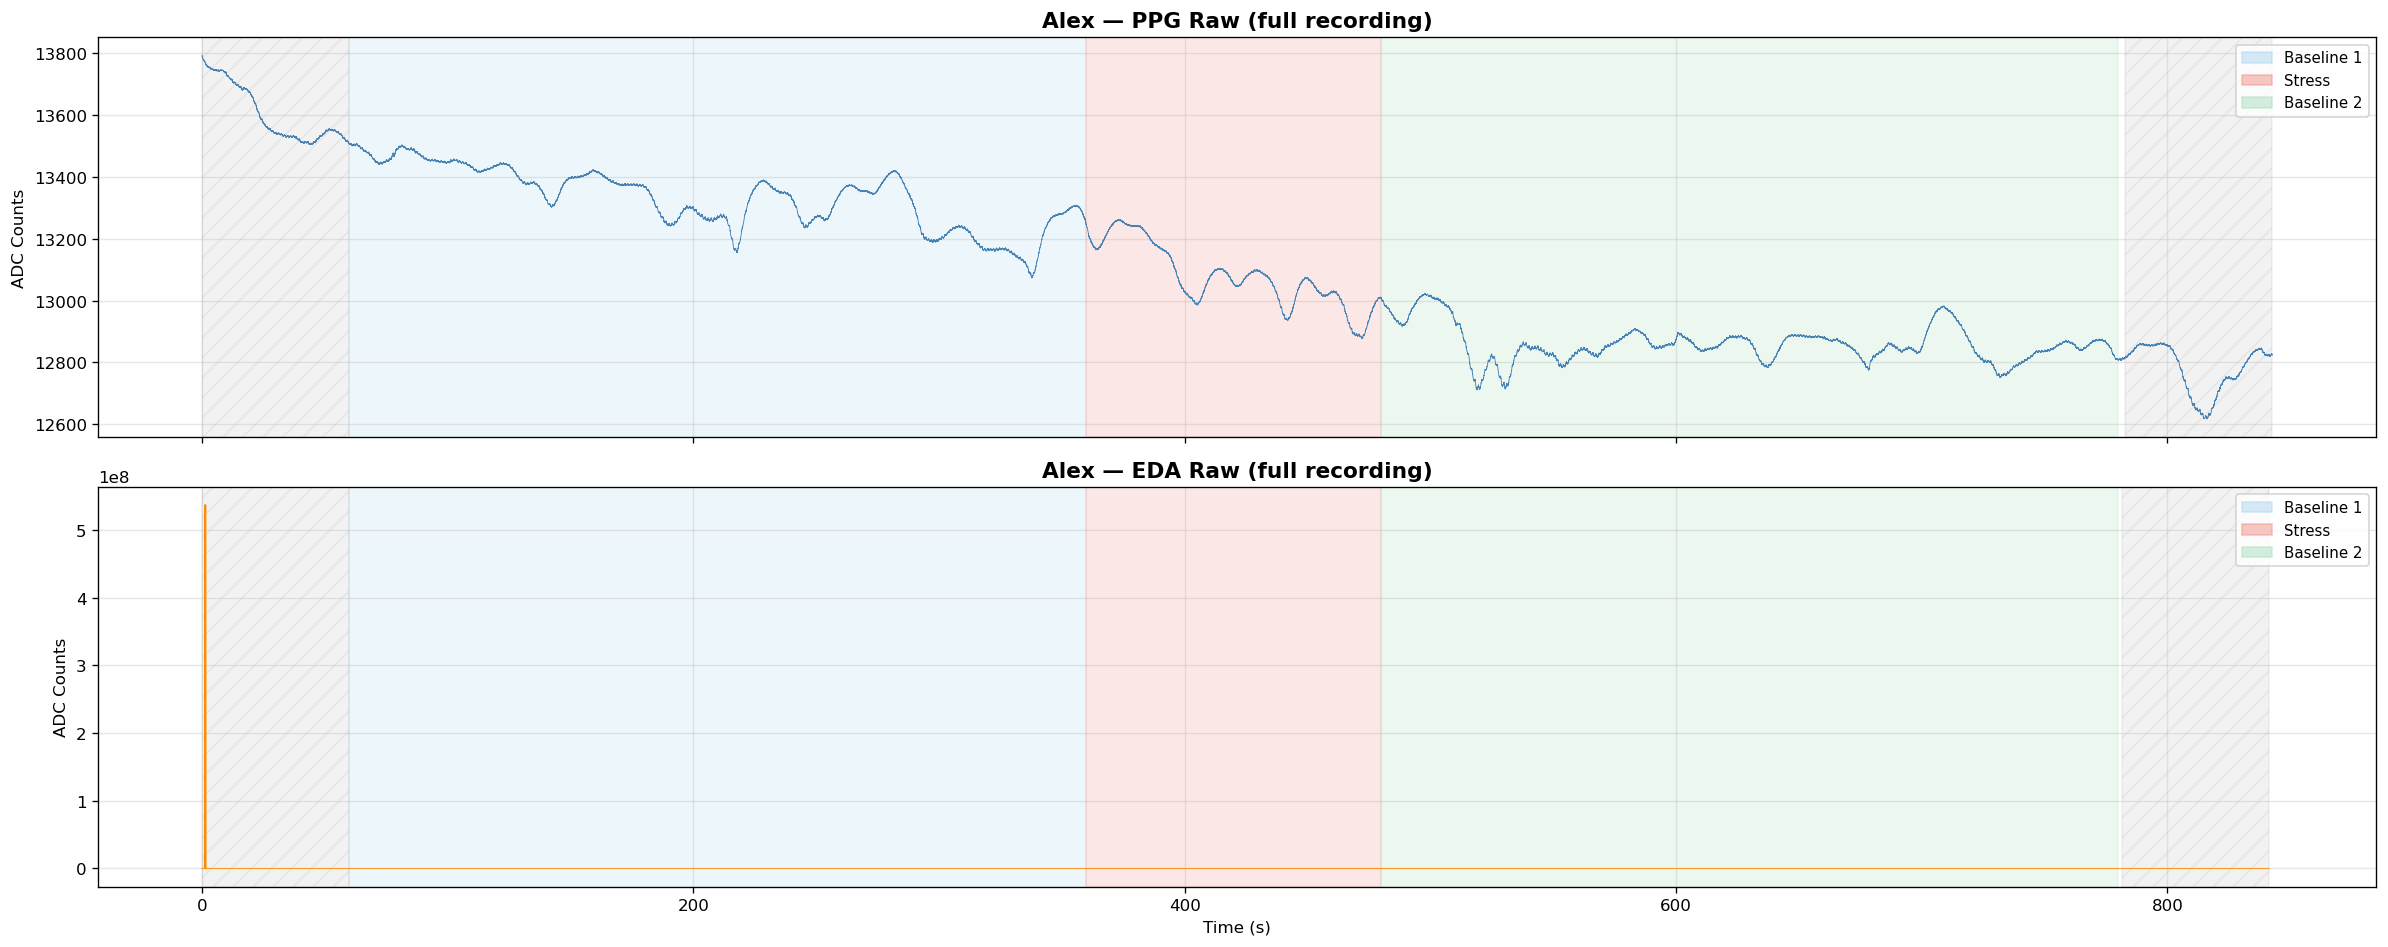

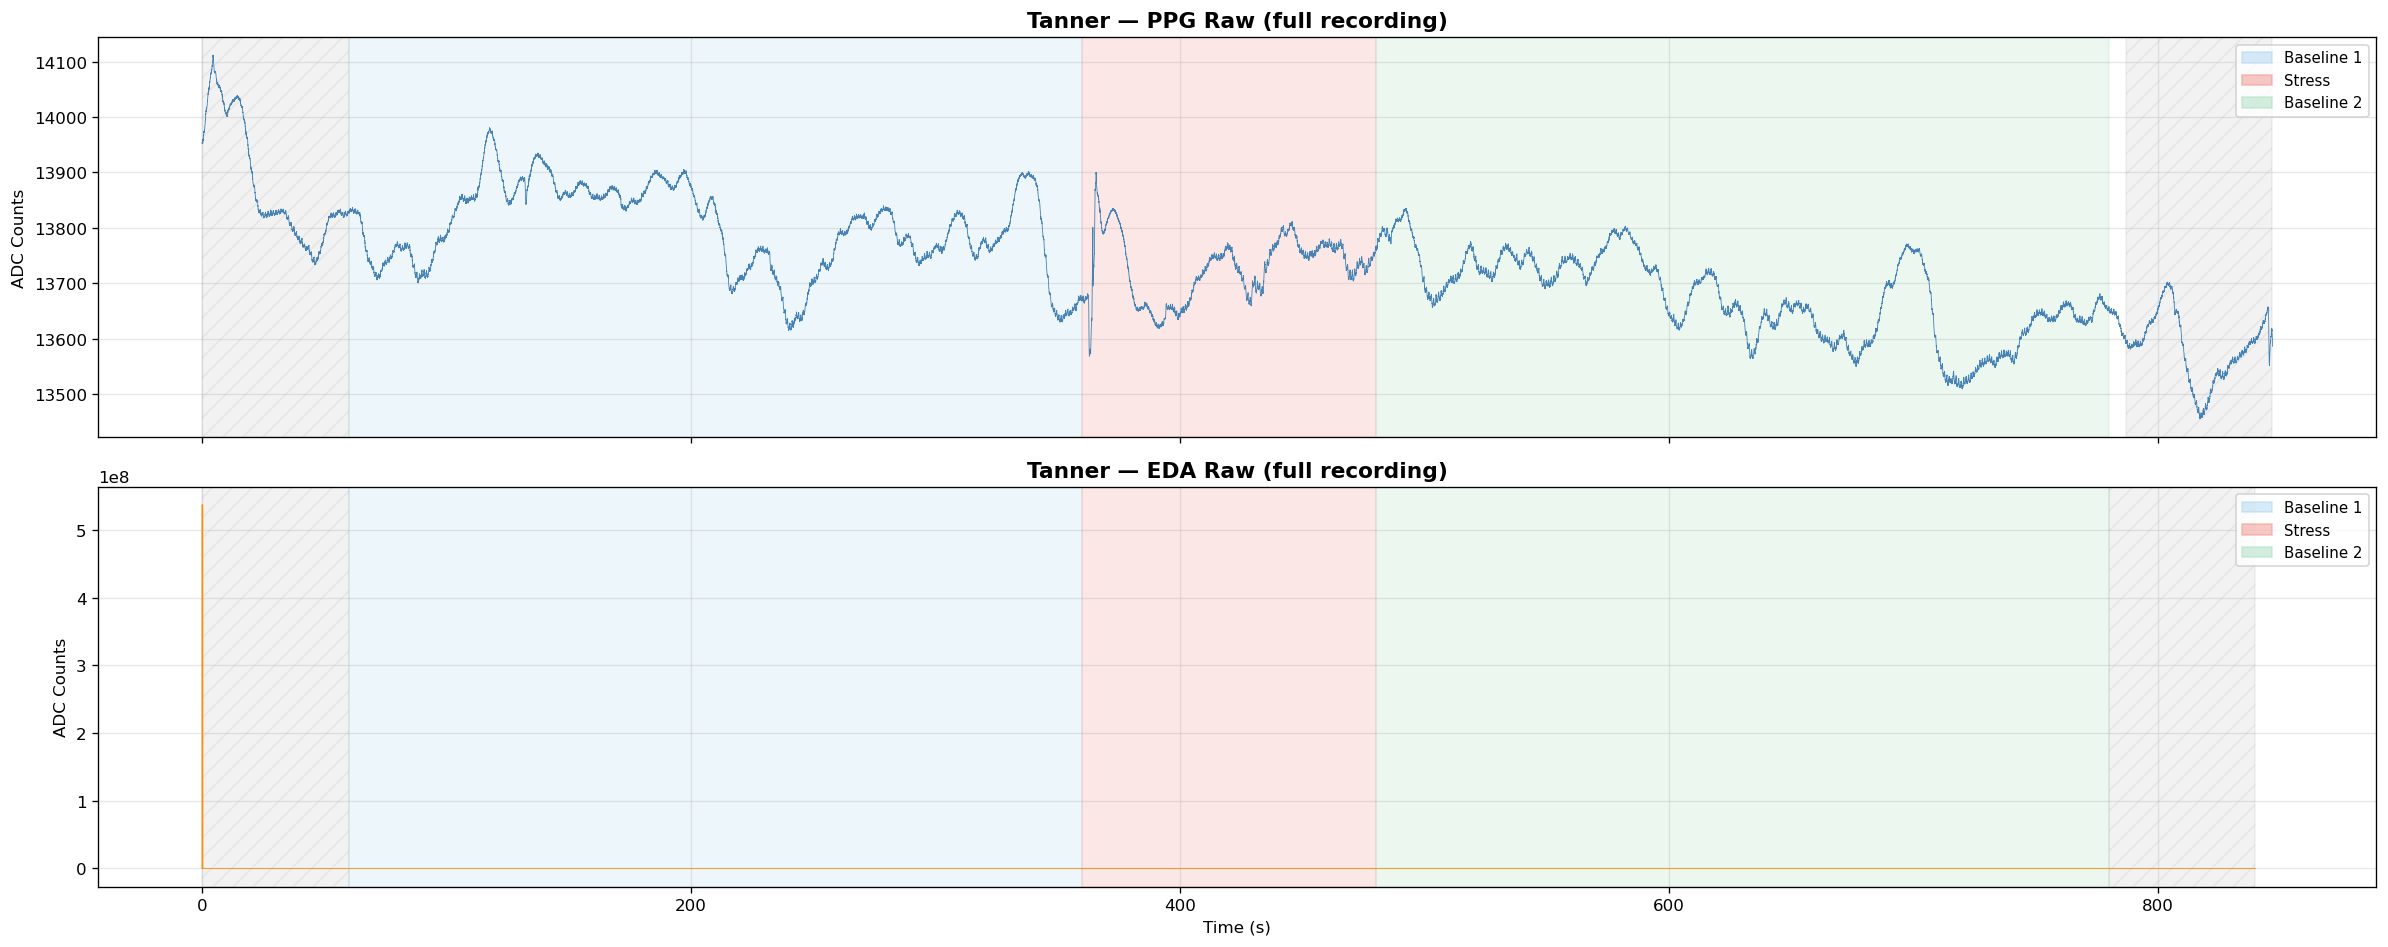

In [2]:
for name, d in data.items():
    fig, axes = plt.subplots(2, 1, figsize=(20, 8), sharex=True)

    # PPG
    axes[0].plot(d['ppg_sec'], d['ppg_df']['ppg'].values, color='steelblue', linewidth=0.5)
    shade_phases(axes[0])
    phase_legend(axes[0])
    axes[0].set_title(f'{name} — PPG Raw (full recording)', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('ADC Counts')
    axes[0].grid(True, alpha=0.3)
    # Mark trim zones
    axes[0].axvspan(0, TRIM_START, alpha=0.10, color='gray', hatch='//')
    axes[0].axvspan(d['ppg_total'] - TRIM_END_OFFSET, d['ppg_total'], alpha=0.10, color='gray', hatch='//')

    # EDA
    axes[1].plot(d['eda_sec'], d['eda_df']['eda'].values, color='darkorange', linewidth=0.5)
    shade_phases(axes[1])
    phase_legend(axes[1])
    axes[1].set_title(f'{name} — EDA Raw (full recording)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('ADC Counts')
    axes[1].set_xlabel('Time (s)')
    axes[1].grid(True, alpha=0.3)
    axes[1].axvspan(0, TRIM_START, alpha=0.10, color='gray', hatch='//')
    axes[1].axvspan(d['eda_total'] - TRIM_END_OFFSET, d['eda_total'], alpha=0.10, color='gray', hatch='//')

    plt.tight_layout()
    plt.show()

## EDA Processing — Artifact Rejection, Tonic/Phasic Decomposition

In [3]:
for name, d in data.items():
    fs = d['fs_eda']
    nyq = fs / 2.0
    eda_sec = d['eda_sec']
    raw_eda = d['eda_df']['eda'].values.astype(float)

    # ── Artifact rejection ──────────────────────────────────────────
    # Flag samples outside a plausible range using median-based thresholding.
    # This catches Tanner's 536M spikes and similar glitches.
    median_val = np.median(raw_eda)
    mad = np.median(np.abs(raw_eda - median_val))  # median absolute deviation
    threshold = 10 * mad  # generous threshold
    artifact_mask = np.abs(raw_eda - median_val) > threshold
    n_artifacts = artifact_mask.sum()

    clean_eda = raw_eda.copy()
    if n_artifacts > 0:
        # Interpolate over artifacts
        good_idx = np.where(~artifact_mask)[0]
        bad_idx = np.where(artifact_mask)[0]
        clean_eda[bad_idx] = np.interp(bad_idx, good_idx, clean_eda[good_idx])
        print(f'{name}: removed {n_artifacts} artifact samples ({n_artifacts/len(raw_eda)*100:.2f}%) via MAD thresholding')
    else:
        print(f'{name}: no artifacts detected')

    # ── Smoothing (1.0 Hz lowpass) ──────────────────────────────────
    b1, a1 = butter(2, 1.0 / nyq, btype='low')
    smoothed = filtfilt(b1, a1, clean_eda)

    # ── Tonic component (0.05 Hz lowpass) ───────────────────────────
    b2, a2 = butter(2, 0.05 / nyq, btype='low')
    tonic = filtfilt(b2, a2, smoothed)

    # ── Phasic component (smoothed − tonic) ─────────────────────────
    phasic = smoothed - tonic

    # ── Trim to analysis window ─────────────────────────────────────
    trim_mask = (eda_sec >= TRIM_START) & (eda_sec <= d['trim_end_eda'])
    d['eda_sec_t']   = eda_sec[trim_mask]
    d['eda_raw_t']   = raw_eda[trim_mask]
    d['eda_clean_t'] = clean_eda[trim_mask]
    d['eda_smooth_t'] = smoothed[trim_mask]
    d['eda_tonic_t']  = tonic[trim_mask]
    d['eda_phasic_t'] = phasic[trim_mask]
    print(f'{name}: analysis window {TRIM_START}s – {d["trim_end_eda"]:.0f}s  |  {trim_mask.sum()} samples')
    print()

Alex: removed 523 artifact samples (1.94%) via MAD thresholding
Alex: analysis window 60s – 781s  |  23087 samples

Tanner: removed 609 artifact samples (2.27%) via MAD thresholding
Tanner: analysis window 60s – 780s  |  23035 samples



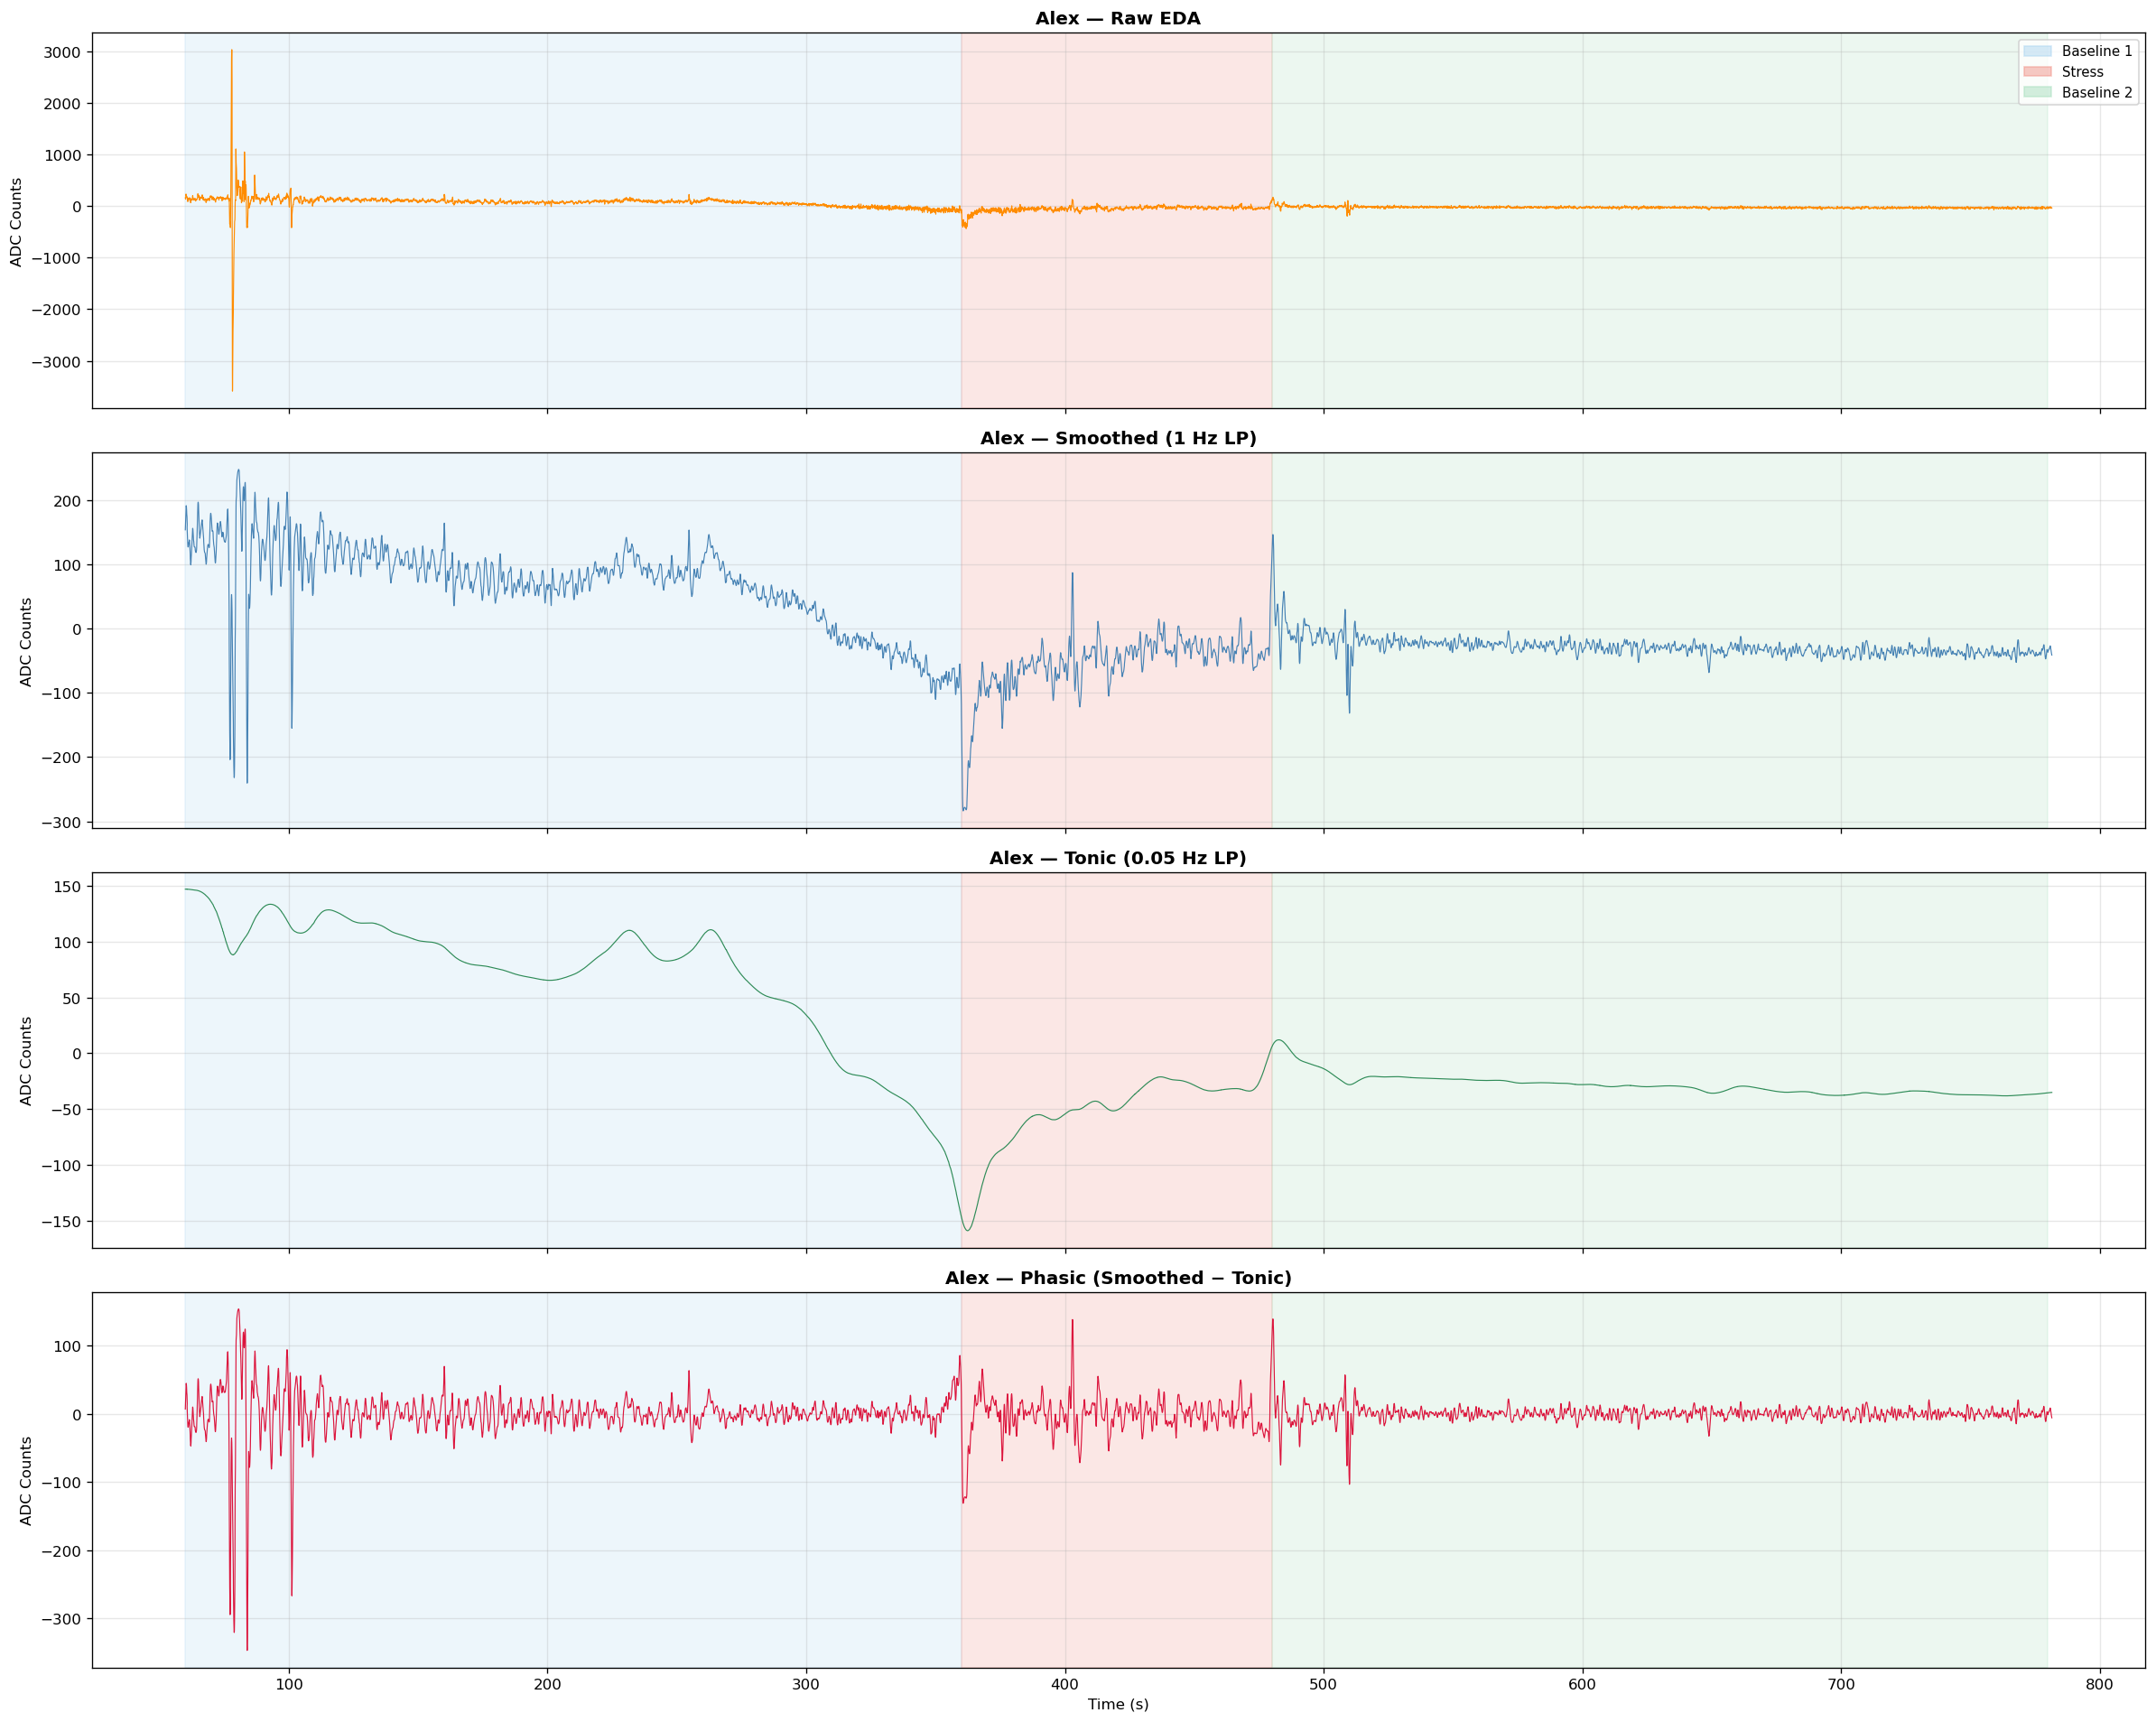

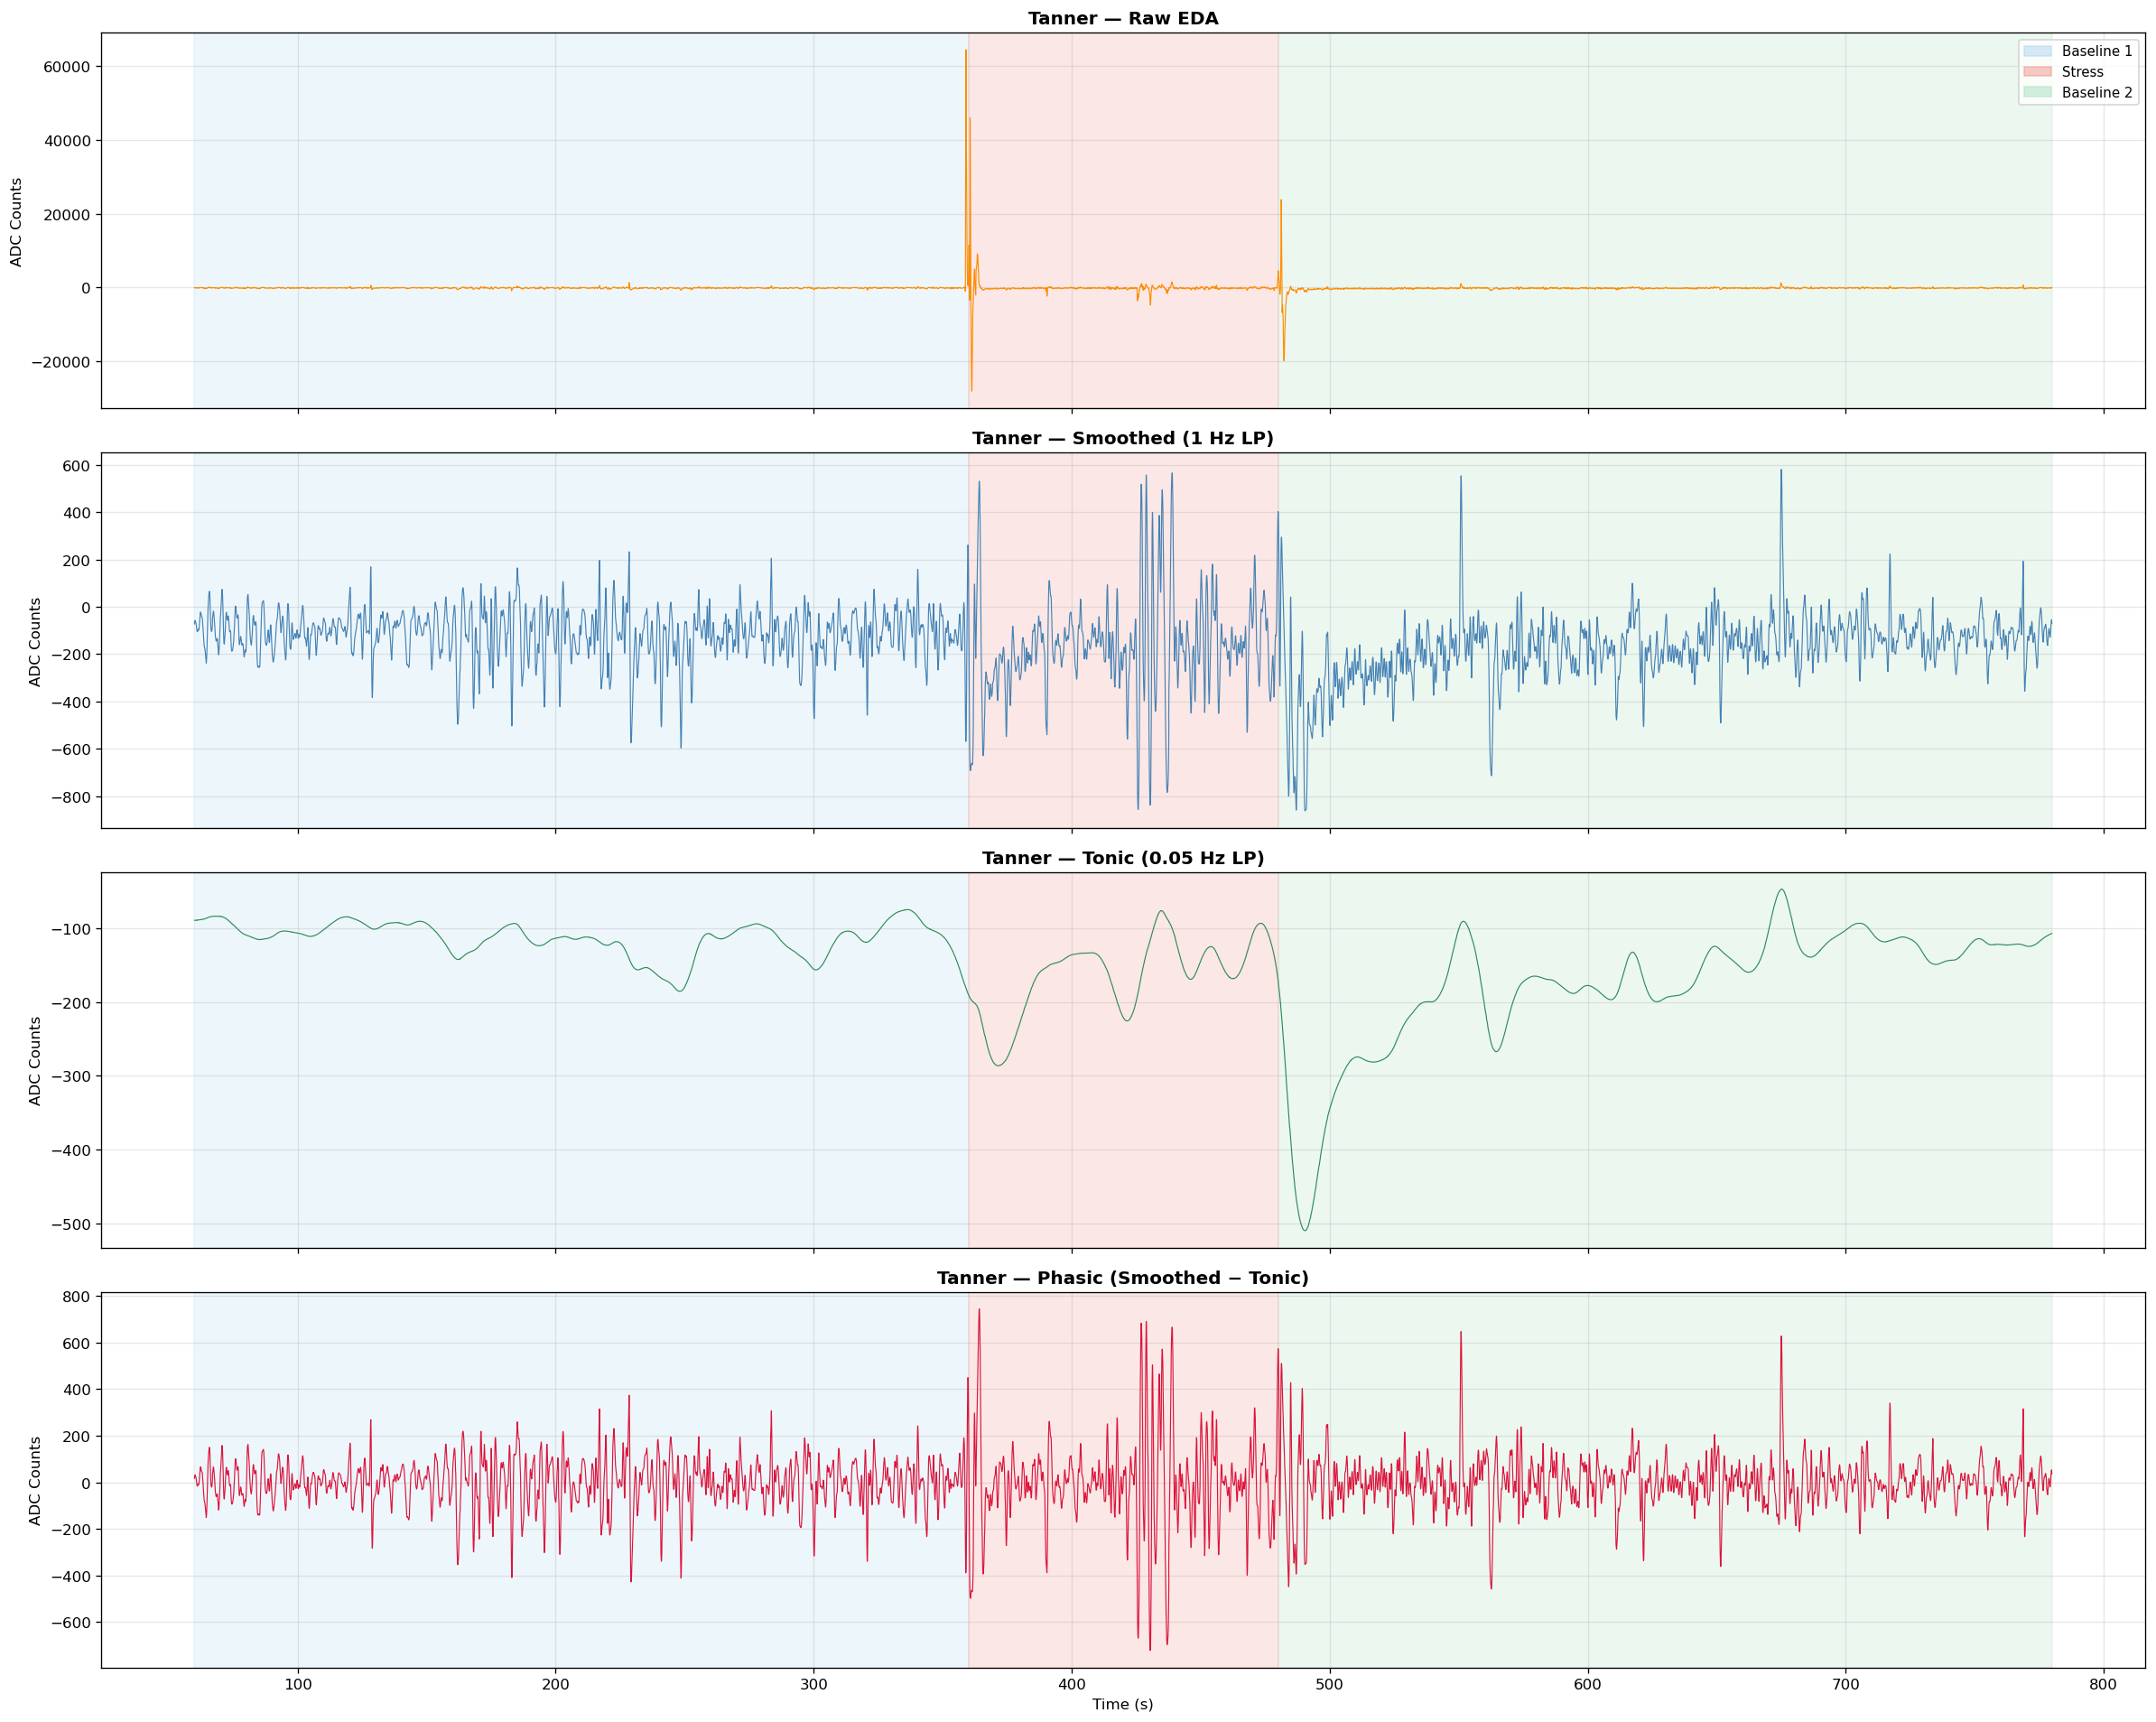

In [4]:
for name, d in data.items():
    t = d['eda_sec_t']

    fig, axes = plt.subplots(4, 1, figsize=(20, 16), sharex=True)
    titles = ['Raw EDA', 'Smoothed (1 Hz LP)', 'Tonic (0.05 Hz LP)', 'Phasic (Smoothed − Tonic)']
    signals = [d['eda_raw_t'], d['eda_smooth_t'], d['eda_tonic_t'], d['eda_phasic_t']]
    colors = ['darkorange', 'steelblue', 'seagreen', 'crimson']

    for ax, title, sig, c in zip(axes, titles, signals, colors):
        shade_phases(ax)
        ax.plot(t, sig, color=c, linewidth=0.7)
        ax.set_title(f'{name} — {title}', fontweight='bold')
        ax.set_ylabel('ADC Counts')
        ax.grid(True, alpha=0.3)

    phase_legend(axes[0])
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

## Alex EDA — Inverse (1/x) Transform

The hardware outputs a value proportional to skin resistance. Taking the inverse (1/x) converts to a conductance-proportional signal, which is the standard representation for EDA.

In [5]:
d = data['Alex']
fs = d['fs_eda']
nyq = fs / 2.0
eda_sec = d['eda_sec']
raw_eda = d['eda_df']['eda'].values.astype(float)

# ── Artifact rejection (same as before) ─────────────────────────────
median_val = np.median(raw_eda)
mad = np.median(np.abs(raw_eda - median_val))
threshold = 10 * mad
artifact_mask = np.abs(raw_eda - median_val) > threshold
clean_eda = raw_eda.copy()
if artifact_mask.sum() > 0:
    good_idx = np.where(~artifact_mask)[0]
    bad_idx = np.where(artifact_mask)[0]
    clean_eda[bad_idx] = np.interp(bad_idx, good_idx, clean_eda[good_idx])

# ── Inverse transform (1/x) ────────────────────────────────────────
# Replace zeros with tiny value to avoid division by zero
clean_eda_safe = np.where(clean_eda == 0, np.nan, clean_eda)
inv_eda = 1.0 / clean_eda_safe

# Interpolate over any NaN from zero-division
nan_mask = np.isnan(inv_eda)
if nan_mask.any():
    good = np.where(~nan_mask)[0]
    bad = np.where(nan_mask)[0]
    inv_eda[bad] = np.interp(bad, good, inv_eda[good])

# ── Process the inverted signal ─────────────────────────────────────
b1, a1 = butter(2, 1.0 / nyq, btype='low')
inv_smoothed = filtfilt(b1, a1, inv_eda)

b2, a2 = butter(2, 0.05 / nyq, btype='low')
inv_tonic = filtfilt(b2, a2, inv_smoothed)

inv_phasic = inv_smoothed - inv_tonic

# ── Trim ────────────────────────────────────────────────────────────
trim_mask = (eda_sec >= TRIM_START) & (eda_sec <= d['trim_end_eda'])
t = eda_sec[trim_mask]
inv_raw_t = inv_eda[trim_mask]
inv_smooth_t = inv_smoothed[trim_mask]
inv_tonic_t = inv_tonic[trim_mask]
inv_phasic_t = inv_phasic[trim_mask]

print(f'Inverse EDA range: [{inv_raw_t.min():.6f}, {inv_raw_t.max():.6f}]')
print(f'Inverse tonic range: [{inv_tonic_t.min():.6f}, {inv_tonic_t.max():.6f}]')

Inverse EDA range: [-1.000000, 1.000000]
Inverse tonic range: [-0.063557, 0.052996]


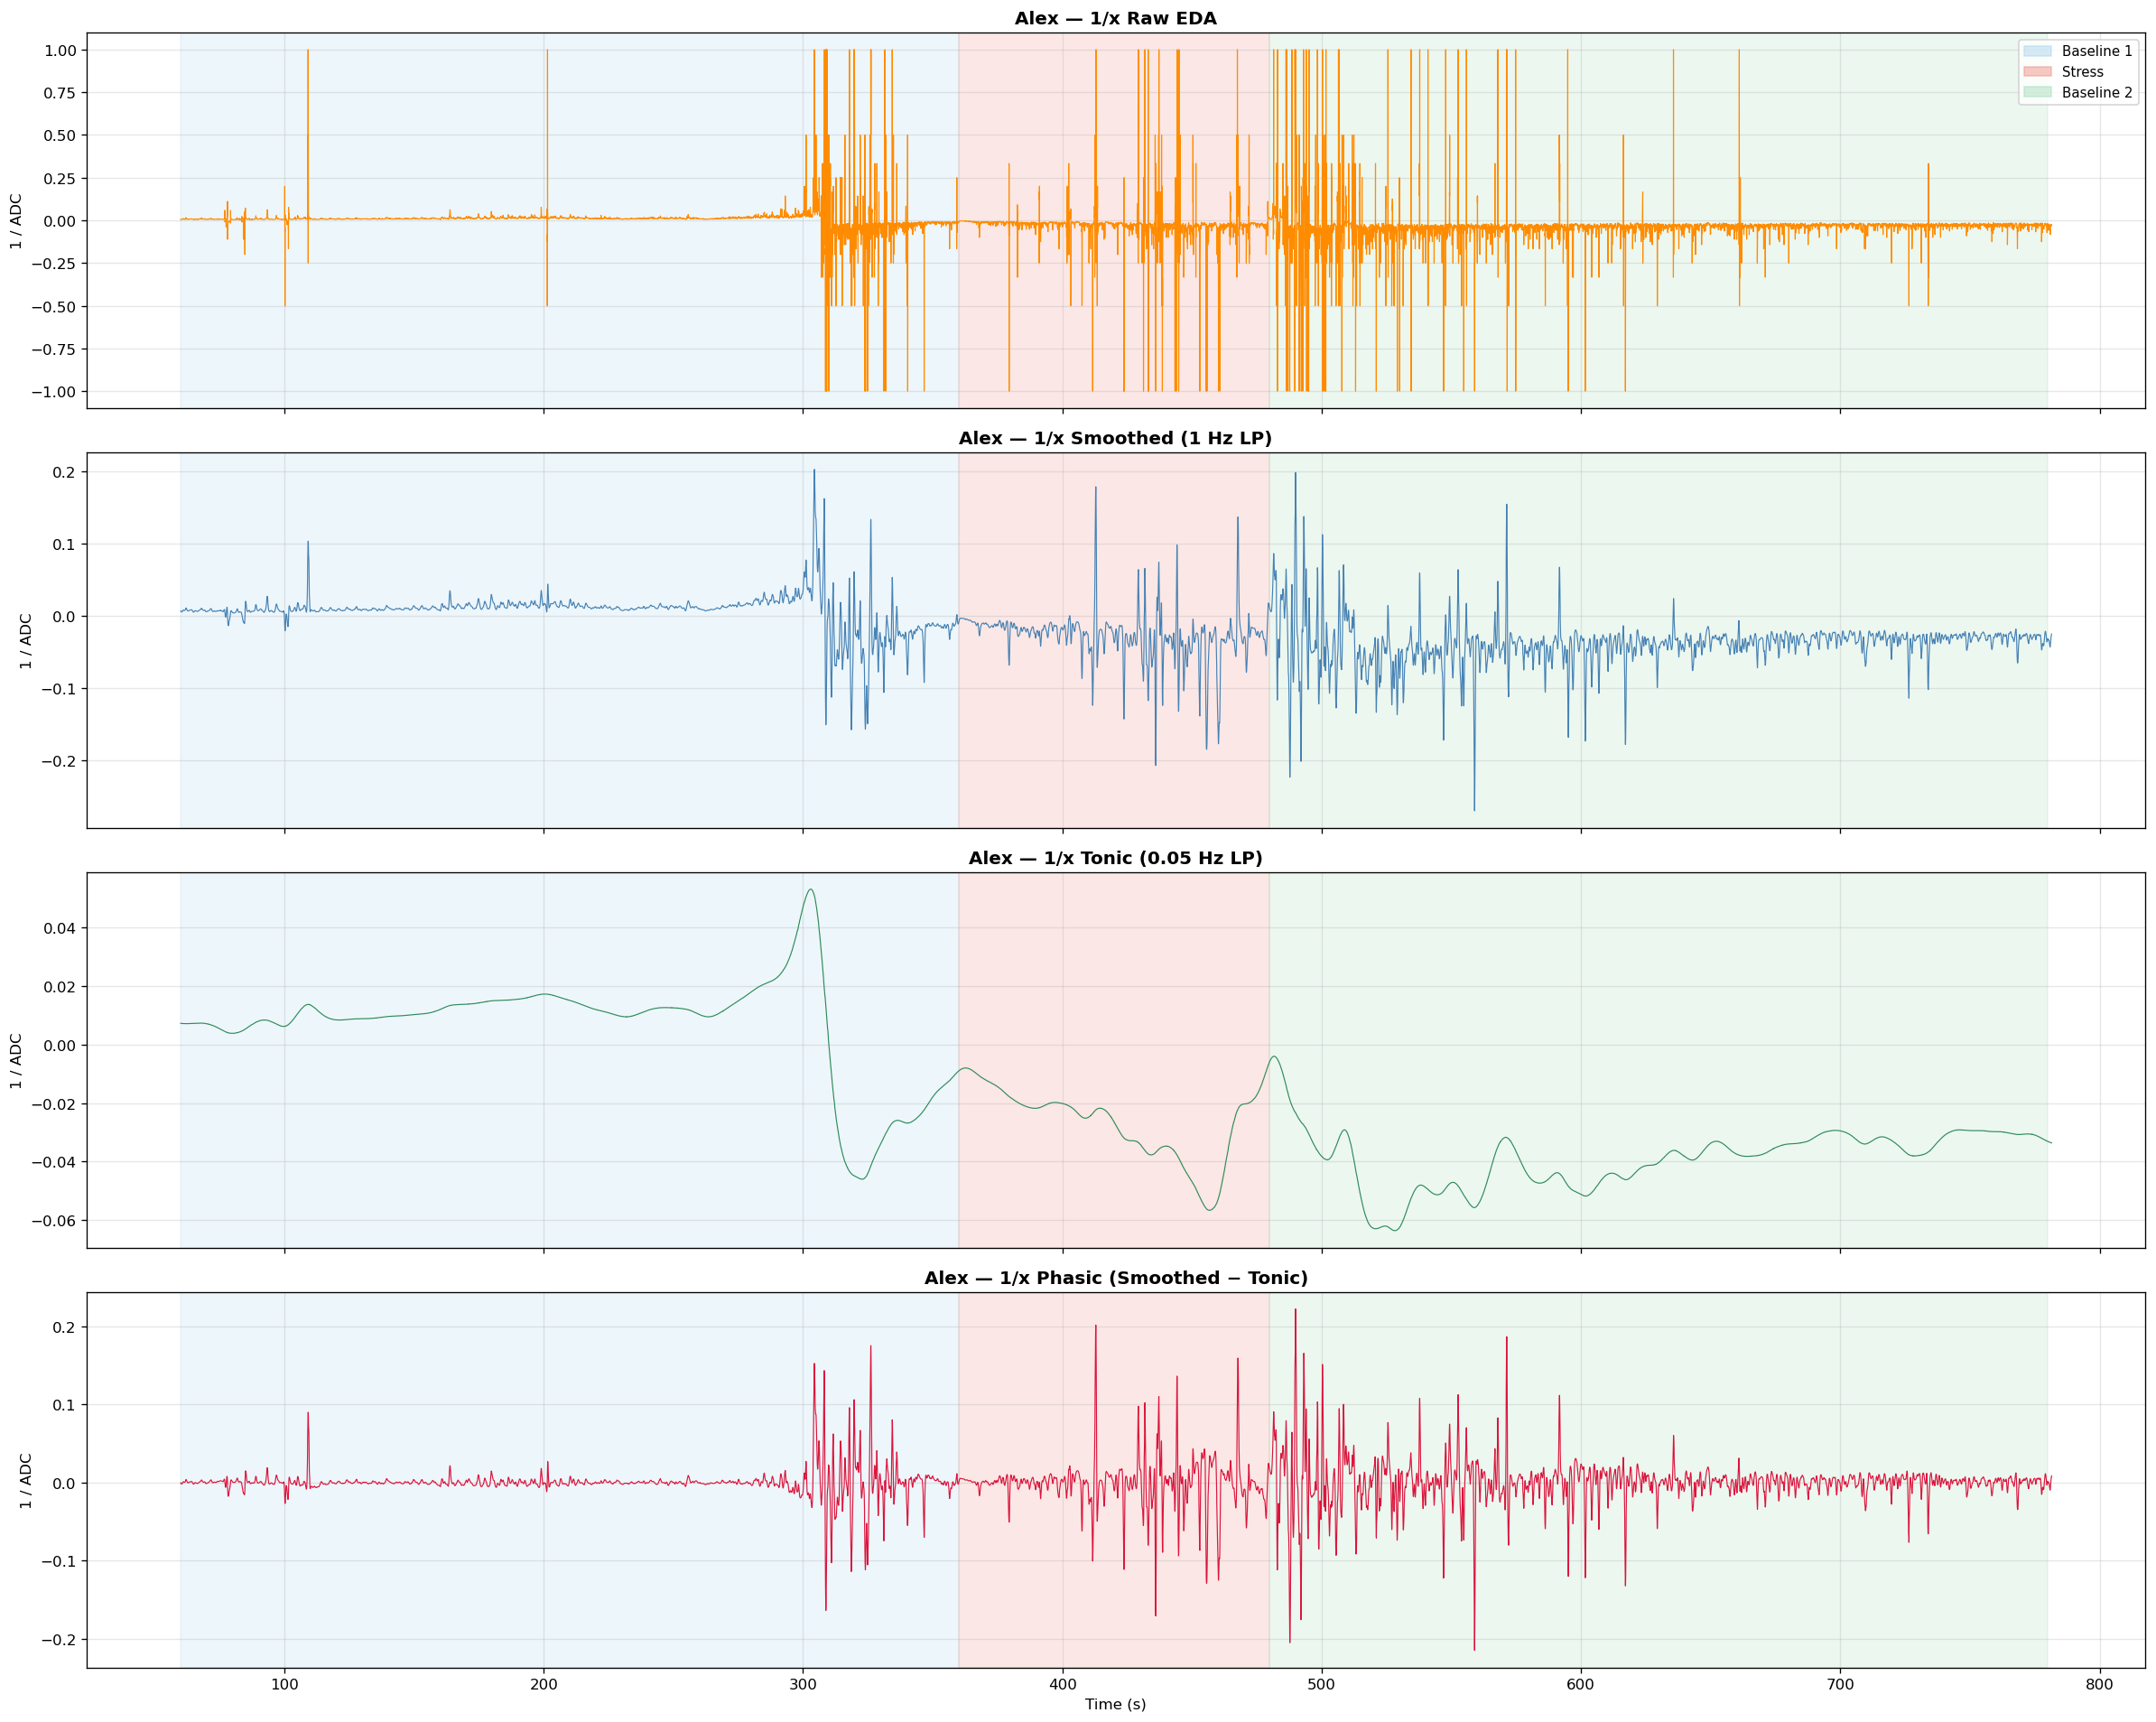

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(20, 16), sharex=True)

titles = ['1/x Raw EDA', '1/x Smoothed (1 Hz LP)', '1/x Tonic (0.05 Hz LP)', '1/x Phasic (Smoothed − Tonic)']
signals = [inv_raw_t, inv_smooth_t, inv_tonic_t, inv_phasic_t]
colors = ['darkorange', 'steelblue', 'seagreen', 'crimson']
ylabels = ['1 / ADC', '1 / ADC', '1 / ADC', '1 / ADC']

for ax, title, sig, c, yl in zip(axes, titles, signals, colors, ylabels):
    shade_phases(ax)
    ax.plot(t, sig, color=c, linewidth=0.7)
    ax.set_title(f'Alex — {title}', fontweight='bold')
    ax.set_ylabel(yl)
    ax.grid(True, alpha=0.3)

phase_legend(axes[0])
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## PPG Processing — Bandpass Filter & Heart Rate Extraction

In [7]:
for name, d in data.items():
    fs = d['fs_ppg']
    nyq = fs / 2.0
    ppg_sec = d['ppg_sec']
    raw_ppg = d['ppg_df']['ppg'].values.astype(float)

    # ── Bandpass filter 0.5–4.0 Hz (cardiac band) ───────────────────
    low, high = 0.5 / nyq, 4.0 / nyq
    b_bp, a_bp = butter(2, [low, high], btype='band')
    ppg_filt = filtfilt(b_bp, a_bp, raw_ppg)

    # ── Trim to analysis window ─────────────────────────────────────
    trim_mask = (ppg_sec >= TRIM_START) & (ppg_sec <= d['trim_end_ppg'])
    t = ppg_sec[trim_mask]
    raw_t = raw_ppg[trim_mask]
    filt_t = ppg_filt[trim_mask]

    # ── Peak detection on filtered PPG ──────────────────────────────
    # Minimum distance between peaks: ~0.33s (180 BPM max)
    min_dist = int(0.33 * fs)
    peaks, props = find_peaks(filt_t, distance=min_dist, prominence=np.std(filt_t) * 0.3)

    # ── Inter-beat intervals → instantaneous HR ─────────────────────
    peak_times = t[peaks]
    ibi = np.diff(peak_times)               # seconds between beats
    hr_inst = 60.0 / ibi                     # BPM
    hr_times = (peak_times[:-1] + peak_times[1:]) / 2  # midpoint time

    # Remove physiologically implausible HR values
    valid = (hr_inst >= 40) & (hr_inst <= 180)
    hr_inst = hr_inst[valid]
    hr_times = hr_times[valid]

    d['ppg_sec_t'] = t
    d['ppg_raw_t'] = raw_t
    d['ppg_filt_t'] = filt_t
    d['ppg_peaks'] = peaks
    d['hr_times'] = hr_times
    d['hr_inst'] = hr_inst

    print(f'{name}: {len(peaks)} beats detected | mean HR = {hr_inst.mean():.1f} BPM | range = [{hr_inst.min():.0f}, {hr_inst.max():.0f}] BPM')
    print()

Alex: 641 beats detected | mean HR = 54.5 BPM | range = [40, 162] BPM

Tanner: 783 beats detected | mean HR = 65.8 BPM | range = [40, 152] BPM



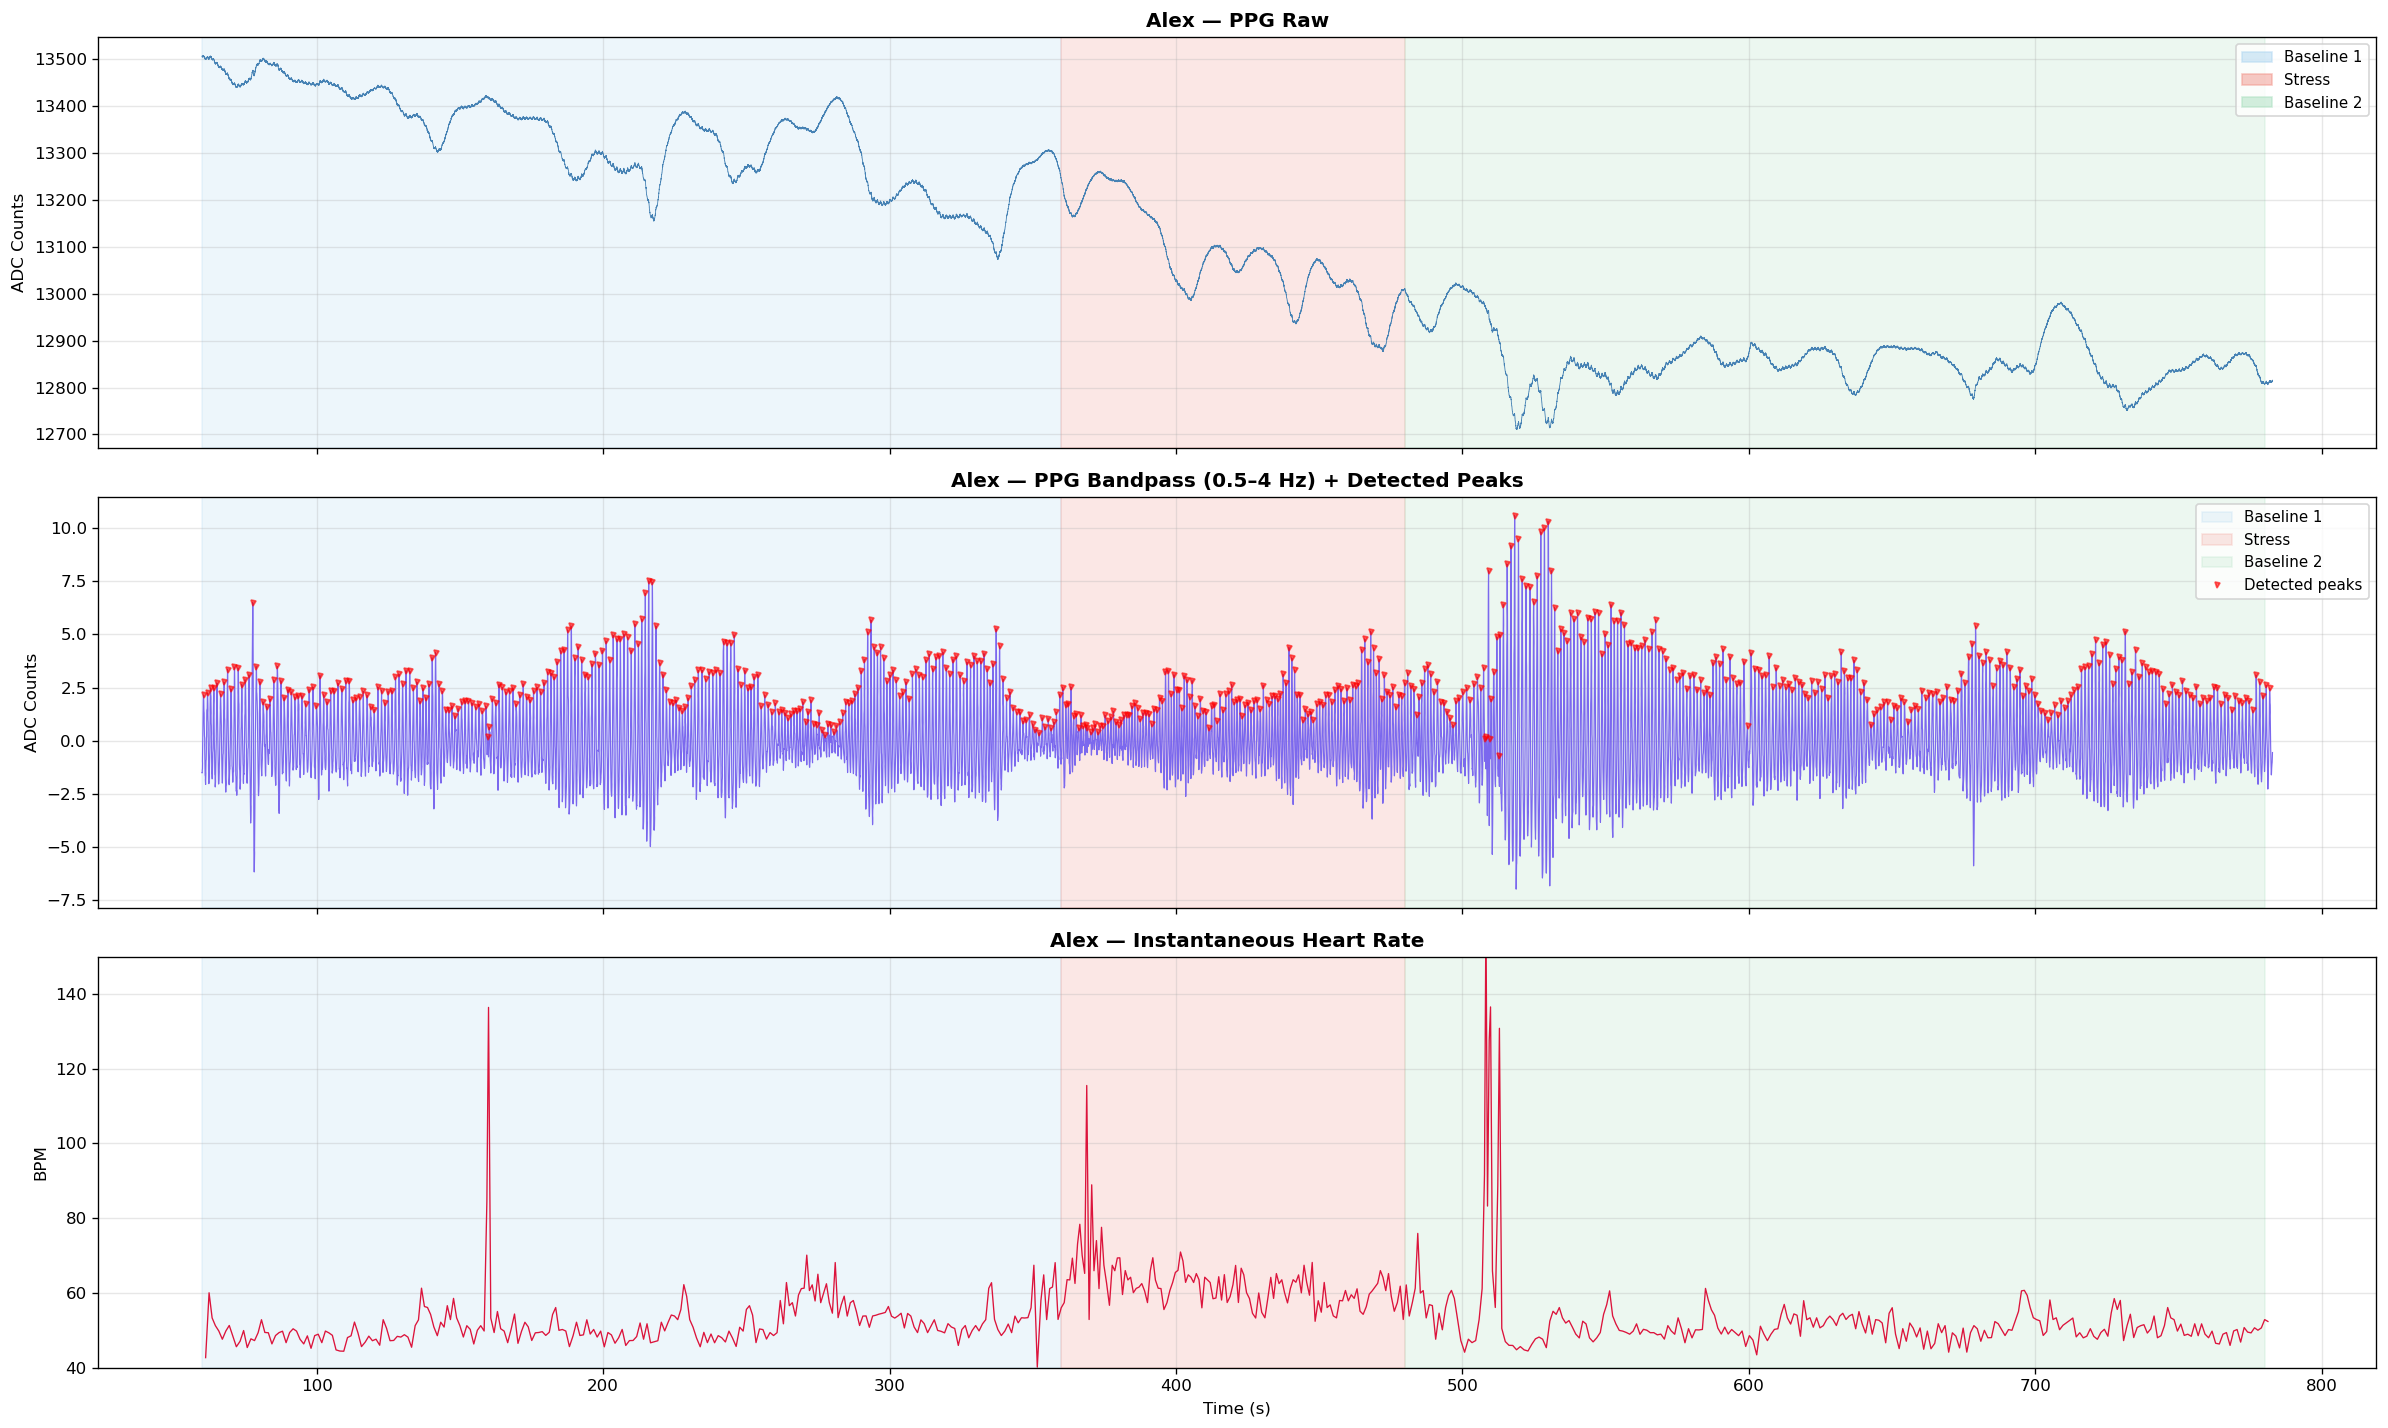

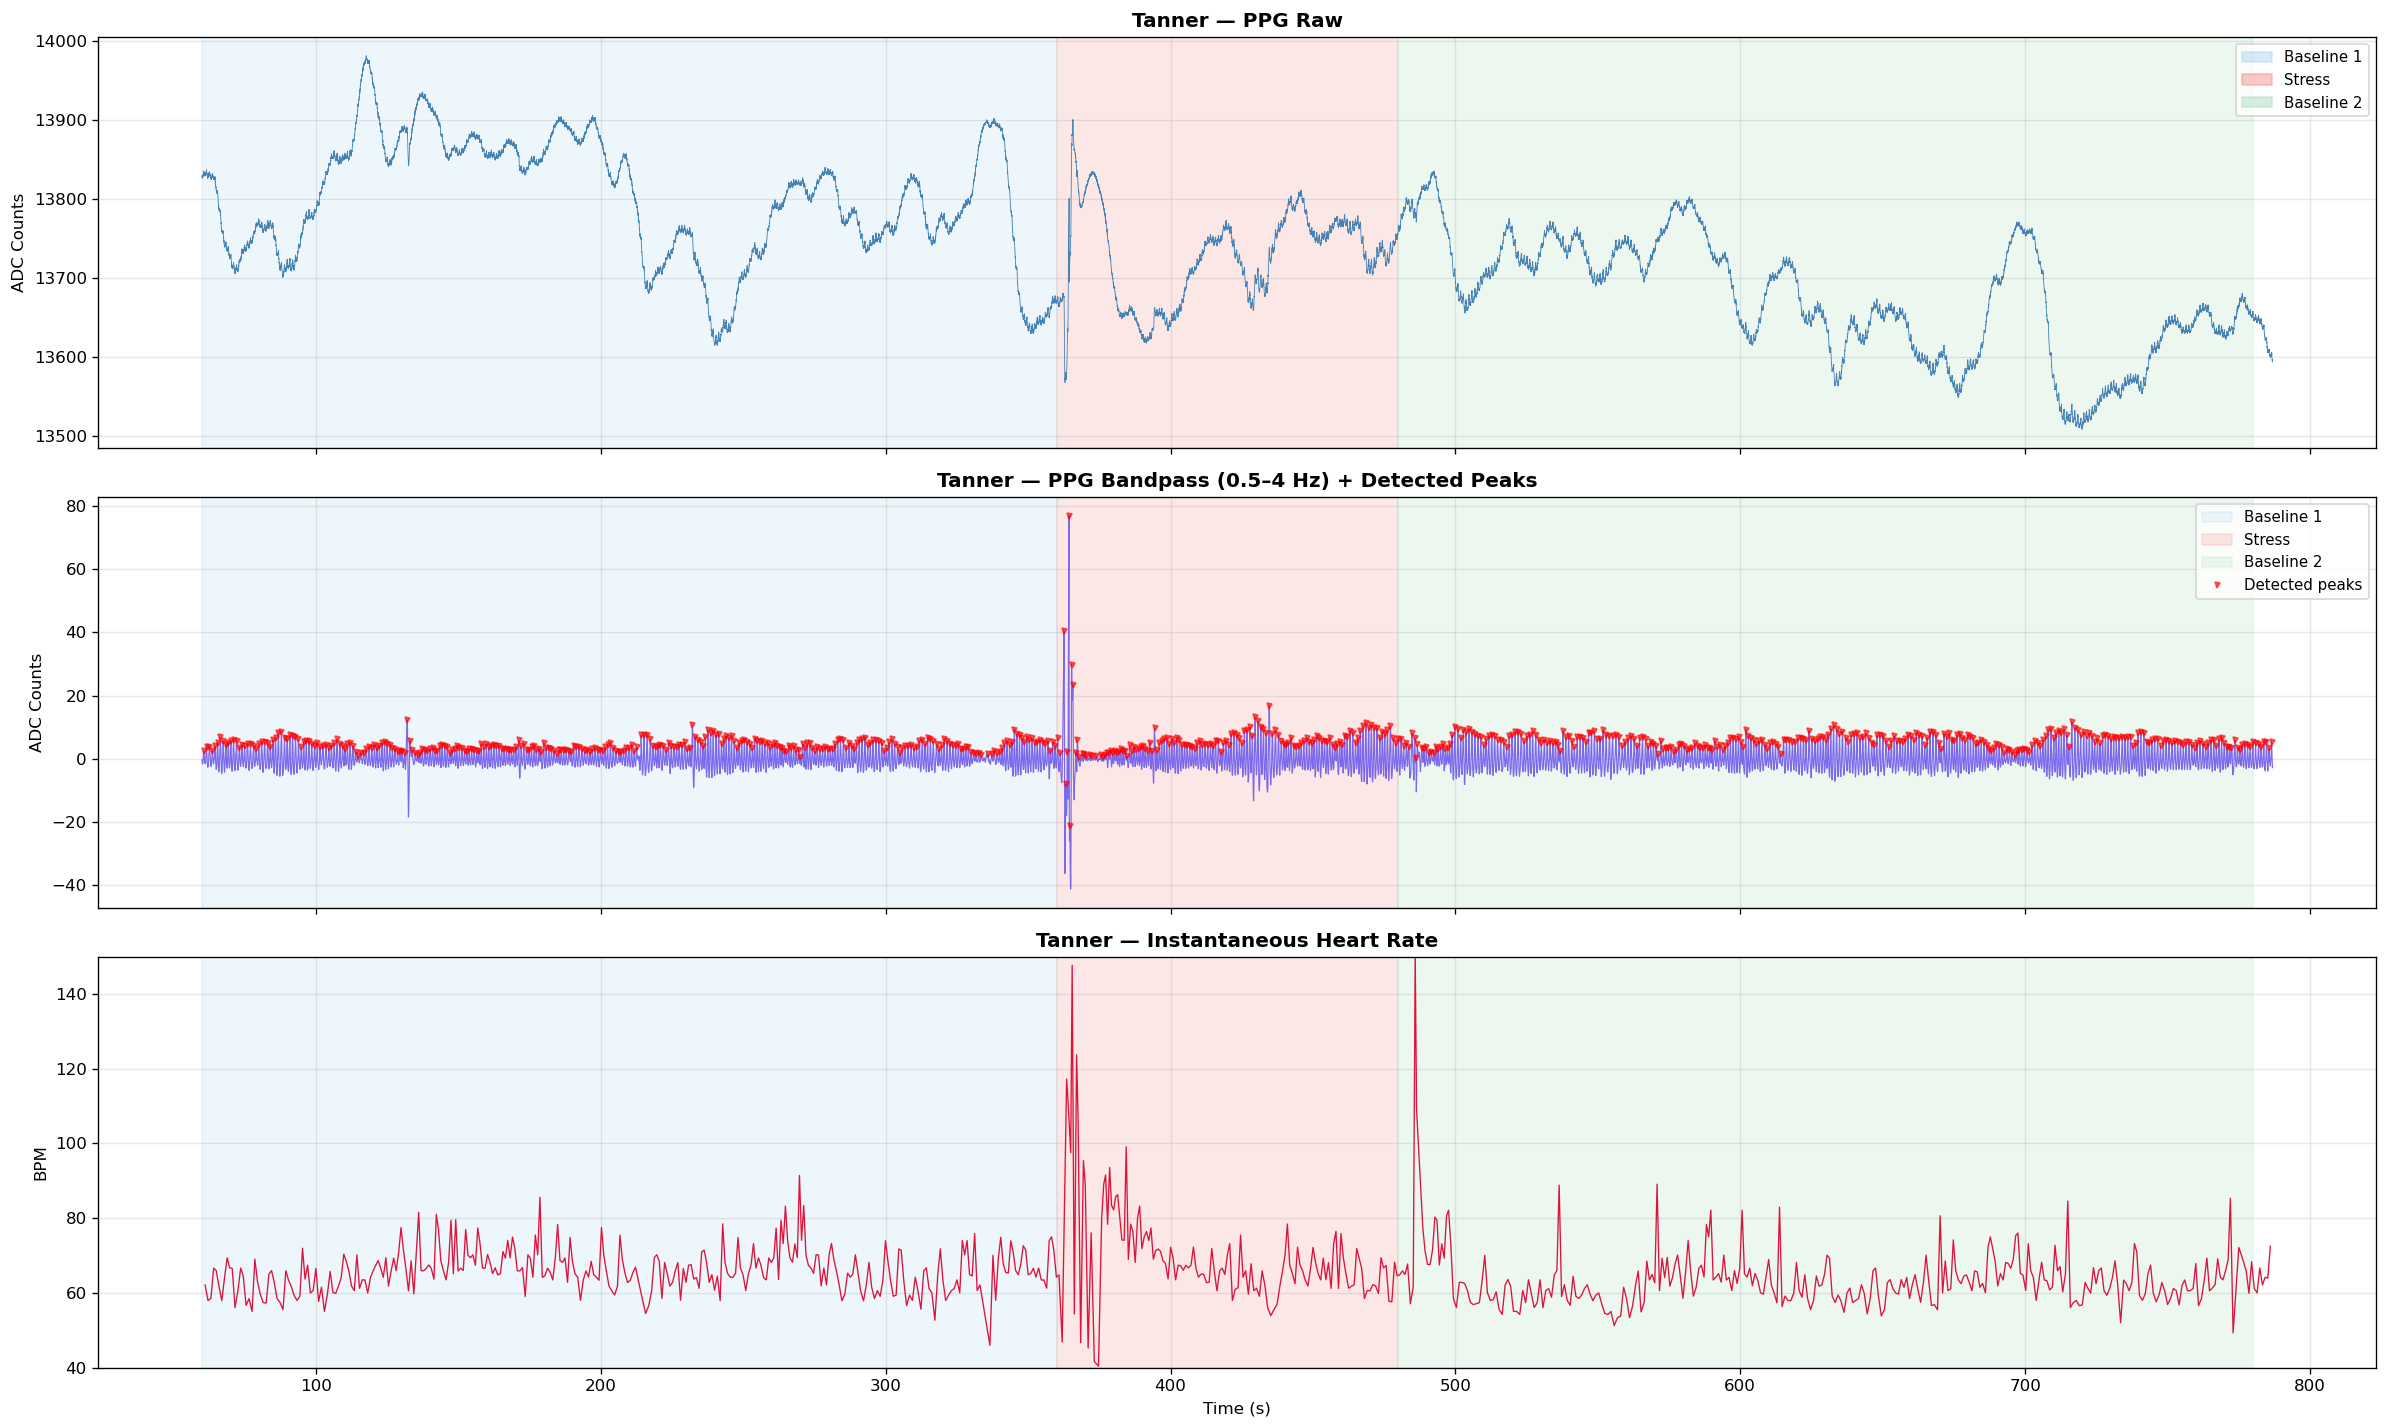

In [8]:
for name, d in data.items():
    t = d['ppg_sec_t']
    fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

    # Raw PPG
    shade_phases(axes[0])
    axes[0].plot(t, d['ppg_raw_t'], color='steelblue', linewidth=0.5)
    axes[0].set_title(f'{name} — PPG Raw', fontweight='bold')
    axes[0].set_ylabel('ADC Counts')
    axes[0].grid(True, alpha=0.3)
    phase_legend(axes[0])

    # Filtered PPG with detected peaks
    shade_phases(axes[1])
    axes[1].plot(t, d['ppg_filt_t'], color='mediumslateblue', linewidth=0.7)
    axes[1].plot(t[d['ppg_peaks']], d['ppg_filt_t'][d['ppg_peaks']], 'rv', markersize=3, alpha=0.6, label='Detected peaks')
    axes[1].set_title(f'{name} — PPG Bandpass (0.5–4 Hz) + Detected Peaks', fontweight='bold')
    axes[1].set_ylabel('ADC Counts')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper right', fontsize=9)

    # Instantaneous Heart Rate
    shade_phases(axes[2])
    axes[2].plot(d['hr_times'], d['hr_inst'], color='crimson', linewidth=0.8)
    axes[2].set_title(f'{name} — Instantaneous Heart Rate', fontweight='bold')
    axes[2].set_ylabel('BPM')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(40, 150)

    plt.tight_layout()
    plt.show()

## Phase-Level Feature Extraction & Comparison

For each subject and each phase (Baseline 1, Stress, Baseline 2), we compute:
- **EDA Tonic Mean** — overall skin conductance level (sympathetic tone)
- **EDA Phasic Std** — variability of phasic bursts (sympathetic reactivity)
- **Mean HR (BPM)** — average heart rate
- **HR Std (BPM)** — heart rate variability proxy (time-domain)
- **RMSSD (ms)** — root mean square of successive IBI differences (parasympathetic indicator)

In [9]:
rows = []

for name, d in data.items():
    for phase, (t0, t1) in PHASES_ABS.items():
        # ── EDA features (use absolute time arrays) ─────────────────
        eda_mask = (d['eda_sec_t'] >= t0) & (d['eda_sec_t'] < t1)
        tonic_seg = d['eda_tonic_t'][eda_mask]
        phasic_seg = d['eda_phasic_t'][eda_mask]

        eda_tonic_mean = tonic_seg.mean() if len(tonic_seg) > 0 else np.nan
        eda_phasic_std = phasic_seg.std() if len(phasic_seg) > 0 else np.nan

        # ── HR features ─────────────────────────────────────────────
        hr_mask = (d['hr_times'] >= t0) & (d['hr_times'] < t1)
        hr_seg = d['hr_inst'][hr_mask]

        hr_mean = hr_seg.mean() if len(hr_seg) > 0 else np.nan
        hr_std  = hr_seg.std() if len(hr_seg) > 0 else np.nan

        # ── RMSSD from IBI ──────────────────────────────────────────
        # Get peak times within this phase
        peak_times_all = d['ppg_sec_t'][d['ppg_peaks']]
        pt_mask = (peak_times_all >= t0) & (peak_times_all < t1)
        pt_seg = peak_times_all[pt_mask]
        if len(pt_seg) > 2:
            ibi_seg = np.diff(pt_seg) * 1000  # ms
            rmssd = np.sqrt(np.mean(np.diff(ibi_seg) ** 2))
        else:
            rmssd = np.nan

        rows.append({
            'Subject': name,
            'Phase': phase,
            'EDA Tonic Mean': eda_tonic_mean,
            'EDA Phasic Std': eda_phasic_std,
            'Mean HR (BPM)': hr_mean,
            'HR Std (BPM)': hr_std,
            'RMSSD (ms)': rmssd,
        })

features_df = pd.DataFrame(rows)
features_df.style.format(precision=2).set_caption('Phase-Level Features')

,Subject,Phase,EDA Tonic Mean,EDA Phasic Std,Mean HR (BPM),HR Std (BPM),RMSSD (ms)
0,Alex,Baseline 1,68.11,34.62,52.08,7.39,110.08
1,Alex,Stress,-51.60,27.41,62.45,7.32,114.10
2,Alex,Baseline 2,-28.38,11.75,53.02,12.35,106.40
3,Tanner,Baseline 1,-113.81,98.37,66.00,5.82,137.71
4,Tanner,Stress,-164.03,204.40,70.27,14.41,193.12
5,Tanner,Baseline 2,-178.66,107.13,63.74,8.45,125.56


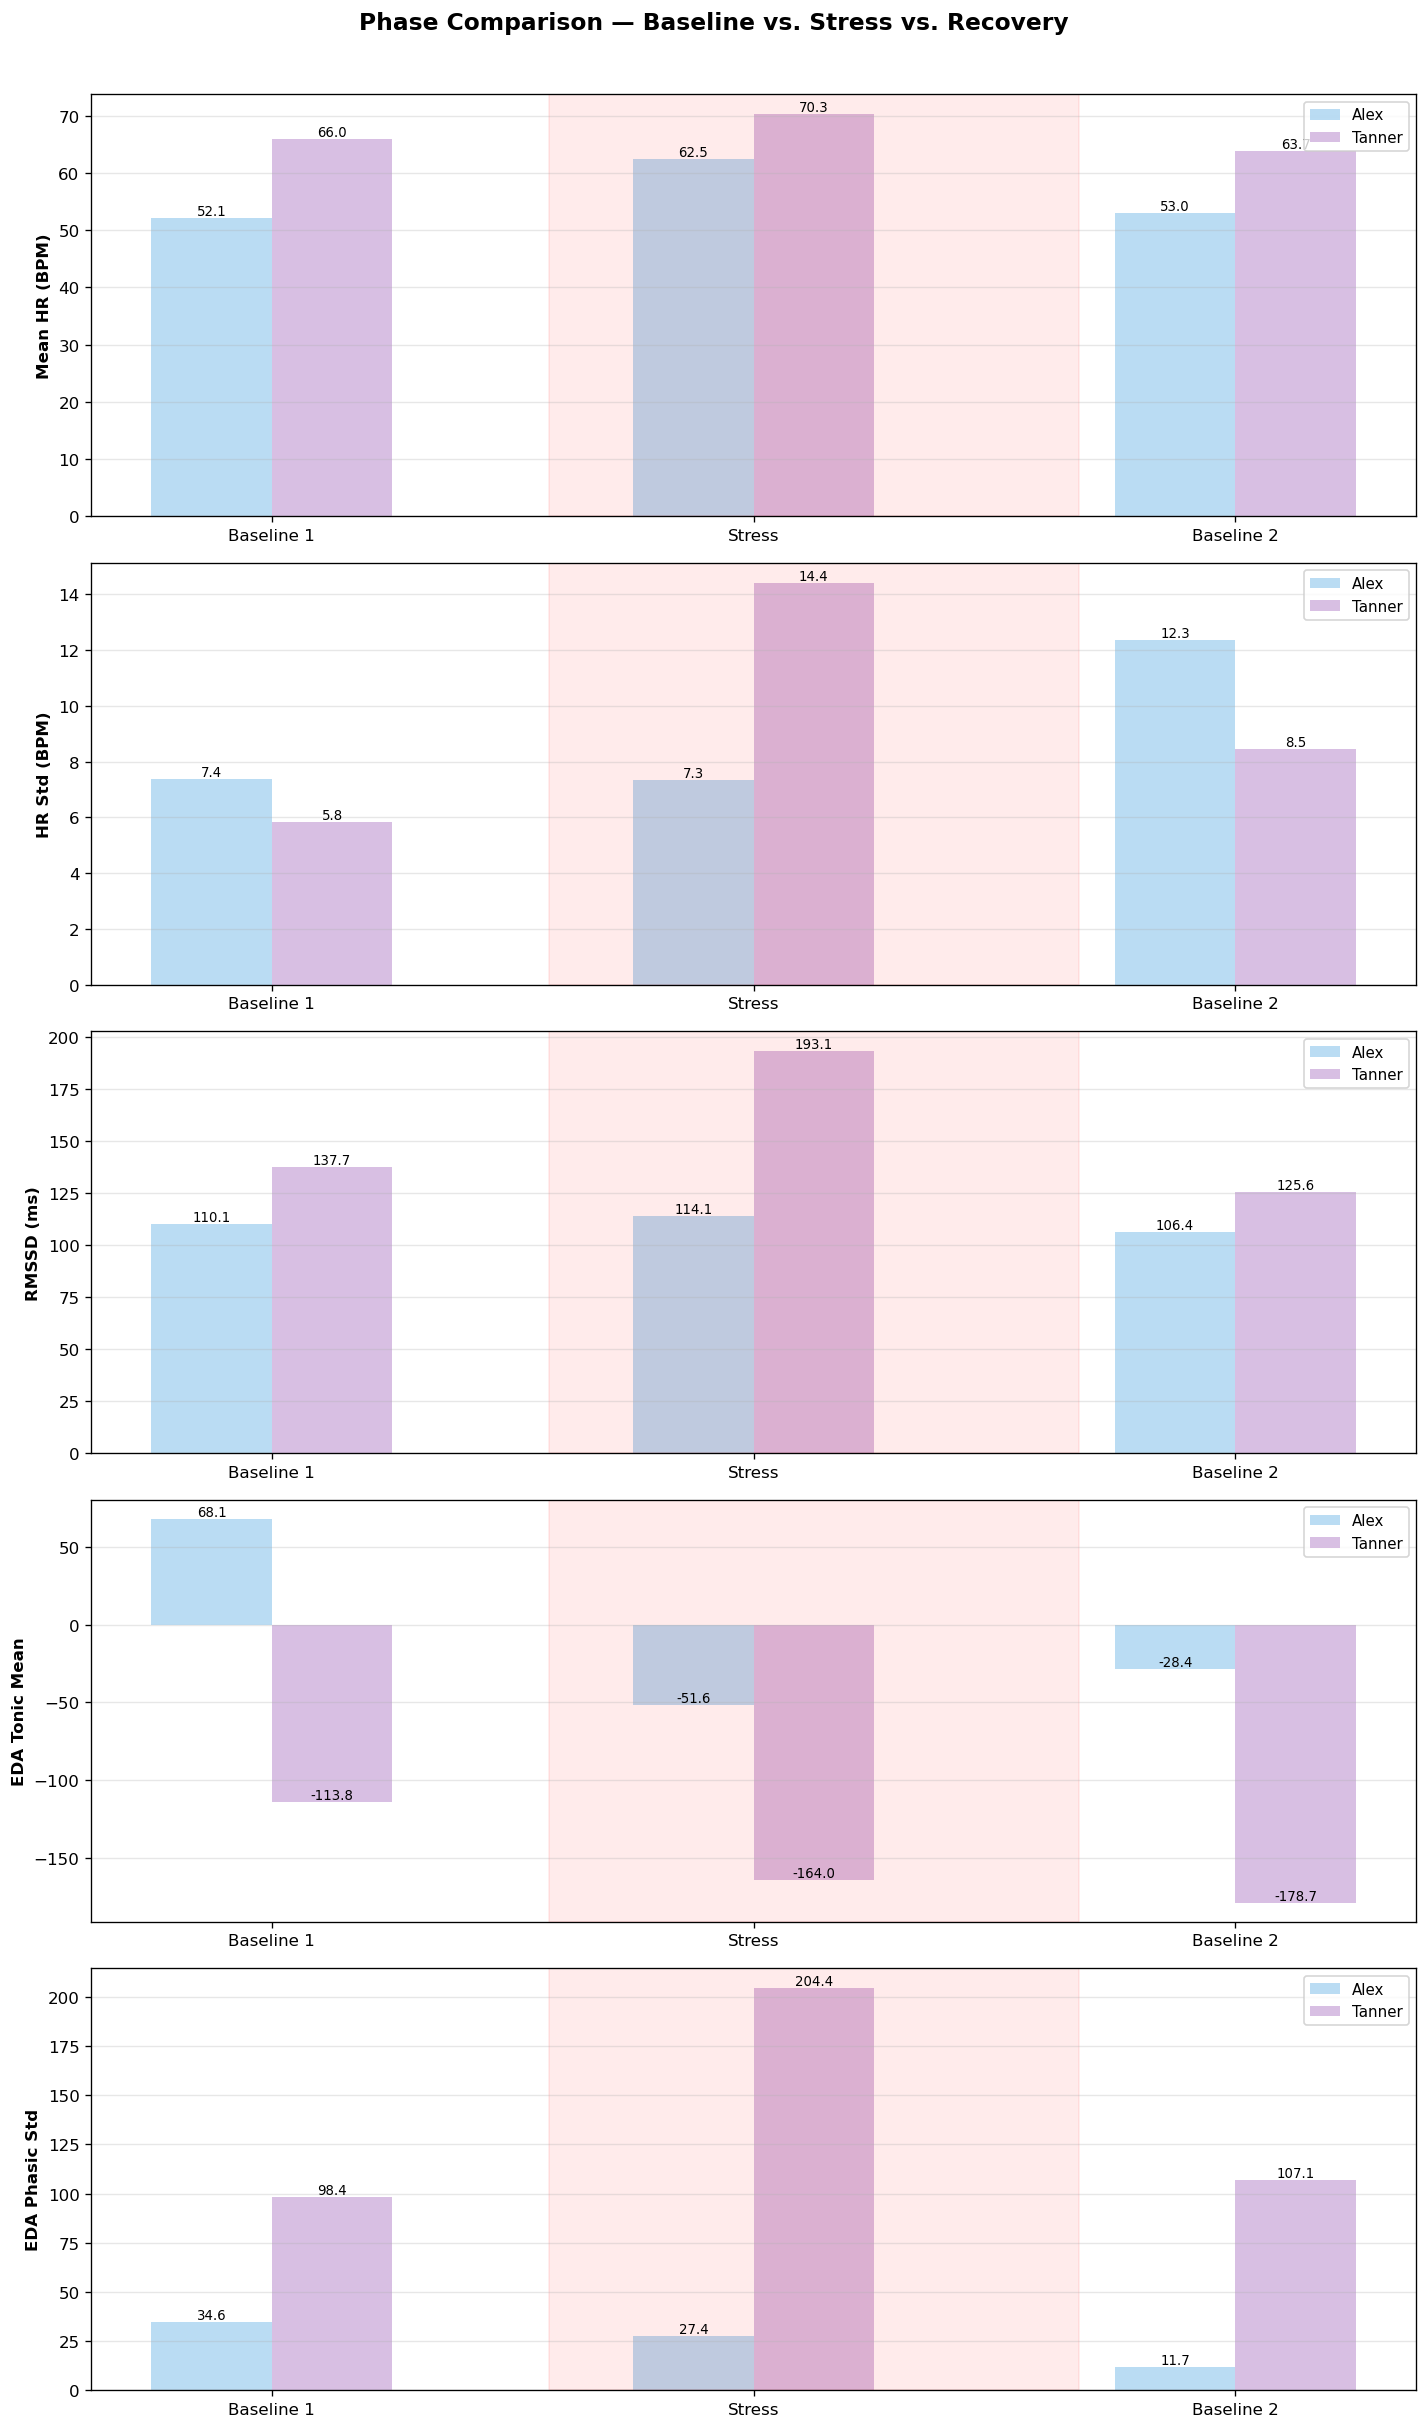

In [10]:
metrics = ['Mean HR (BPM)', 'HR Std (BPM)', 'RMSSD (ms)', 'EDA Tonic Mean', 'EDA Phasic Std']
subjects = list(data.keys())
phases = list(PHASES_ABS.keys())

fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 4 * len(metrics)))

bar_width = 0.25
x = np.arange(len(phases))

for ax, metric in zip(axes, metrics):
    for i, subj in enumerate(subjects):
        vals = features_df[features_df['Subject'] == subj].set_index('Phase').loc[phases, metric].values
        bars = ax.bar(x + i * bar_width, vals, bar_width, label=subj,
                      color=PHASE_COLORS[phases[0]] if i == 0 else '#D2B4DE', alpha=0.85)
        # Value labels on bars
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{v:.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_ylabel(metric, fontweight='bold')
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels(phases)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Highlight stress bar background
    stress_idx = phases.index('Stress')
    ax.axvspan(stress_idx - 0.3, stress_idx + 0.3 + bar_width * len(subjects),
               alpha=0.08, color='red')

fig.suptitle('Phase Comparison — Baseline vs. Stress vs. Recovery', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## HR Overlay — Both Subjects

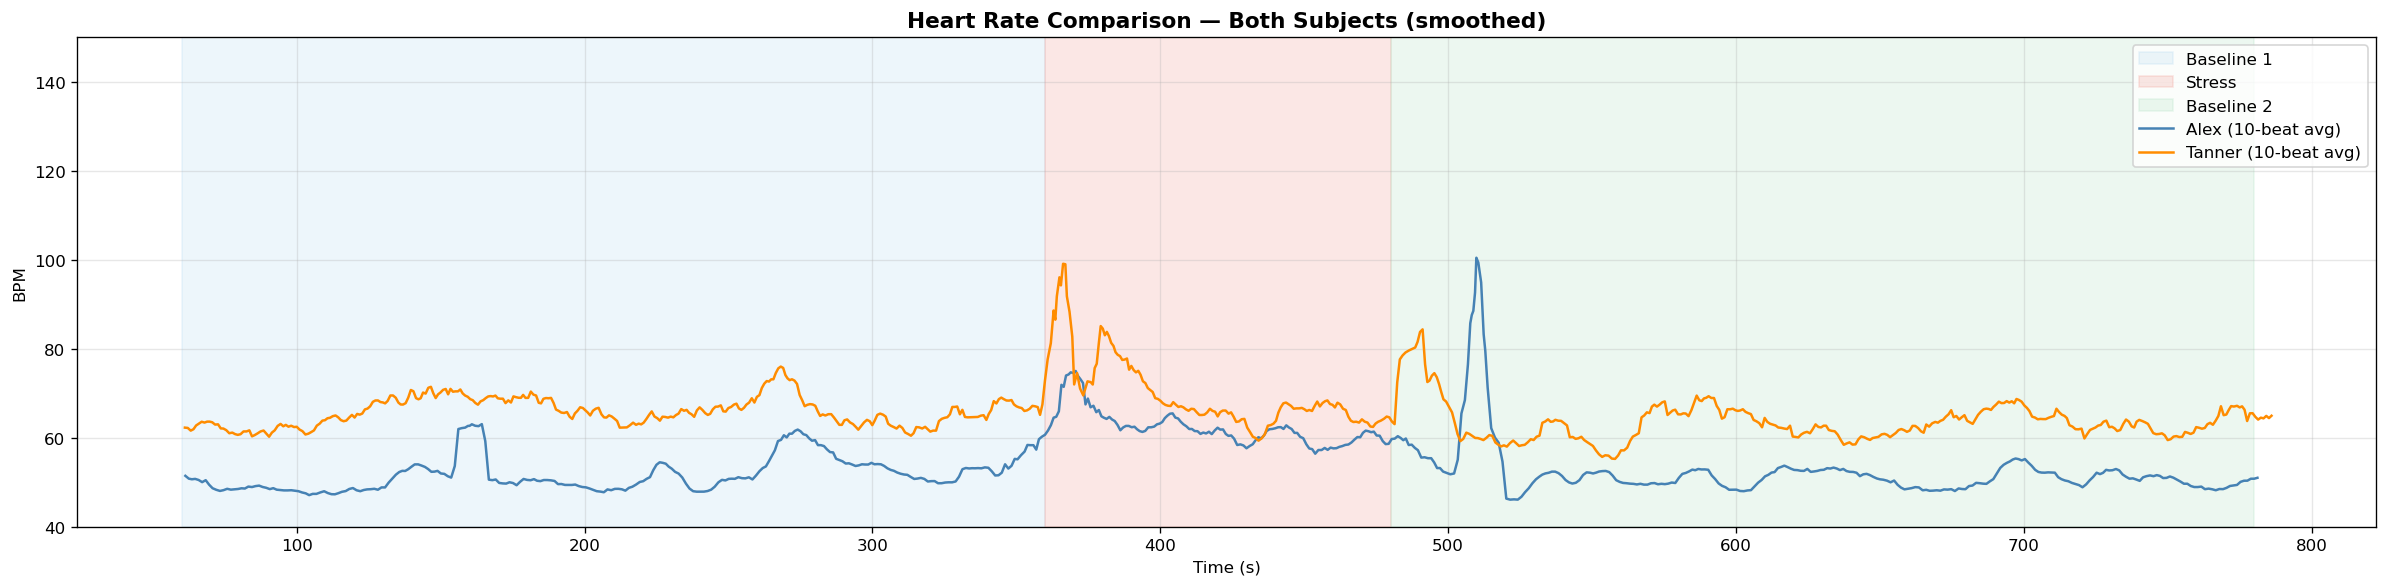

In [11]:
fig, ax = plt.subplots(figsize=(20, 5))

shade_phases(ax)
subj_colors = {'Alex': 'steelblue', 'Tanner': 'darkorange'}

for name, d in data.items():
    # 10-second rolling average for smoother comparison
    hr_df = pd.DataFrame({'t': d['hr_times'], 'hr': d['hr_inst']}).sort_values('t')
    hr_smooth = hr_df.set_index('t')['hr'].rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(hr_df['t'].values, hr_smooth.values, color=subj_colors[name],
            linewidth=1.5, label=f'{name} (10-beat avg)')

phase_legend(ax, loc='upper left')
ax.legend(loc='upper right', fontsize=10)
ax.set_title('Heart Rate Comparison — Both Subjects (smoothed)', fontsize=13, fontweight='bold')
ax.set_ylabel('BPM')
ax.set_xlabel('Time (s)')
ax.set_ylim(40, 150)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## What to Look For

**Expected stress responses (minutes 6–8, Stress phase):**
- **HR increase** — sympathetic activation raises heart rate during cold pressor
- **RMSSD decrease** — reduced parasympathetic tone lowers beat-to-beat variability
- **EDA tonic rise** — skin conductance level increases with sympathetic arousal
- **EDA phasic bursts** — more frequent / larger phasic peaks during stress

**Recovery (minutes 8–13, Baseline 2):**
- Signals should gradually return toward Baseline 1 levels
- Incomplete recovery may indicate sustained sympathetic activation

**Hardware validation checks:**
- Are PPG peaks clearly visible and regularly spaced? (signal quality)
- Does EDA show physiologically plausible values after artifact removal?
- Are sampling rates stable (~100 Hz PPG, ~32 Hz EDA)?
- Do both subjects show consistent sensor behavior?